<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W3-Manasa/W3D3_Decision_Trees_Random_Forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# W3D3: Decision Trees & Random Forests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load the Breast Cancer classification dataset

data = load_breast_cancer(as_frame=True)

df = data.frame

print("Dataset loaded successfully")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully
Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Separate features (X) and target (y)

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:")
print(data.target_names)

Features shape: (569, 30)
Target shape: (569,)

Target classes:
['malignant' 'benign']


In [4]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (455, 30)
Testing features: (114, 30)
Training target: (455,)
Testing target: (114,)


In [5]:
# Create and train a Decision Tree classifier

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [6]:
# Make predictions and evaluate the Decision Tree

y_pred_tree = decision_tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Performance")
print("-------------------------")
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Performance
-------------------------
Accuracy: 0.9123

Classification Report:
              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Confusion Matrix:
[[39  3]
 [ 7 65]]


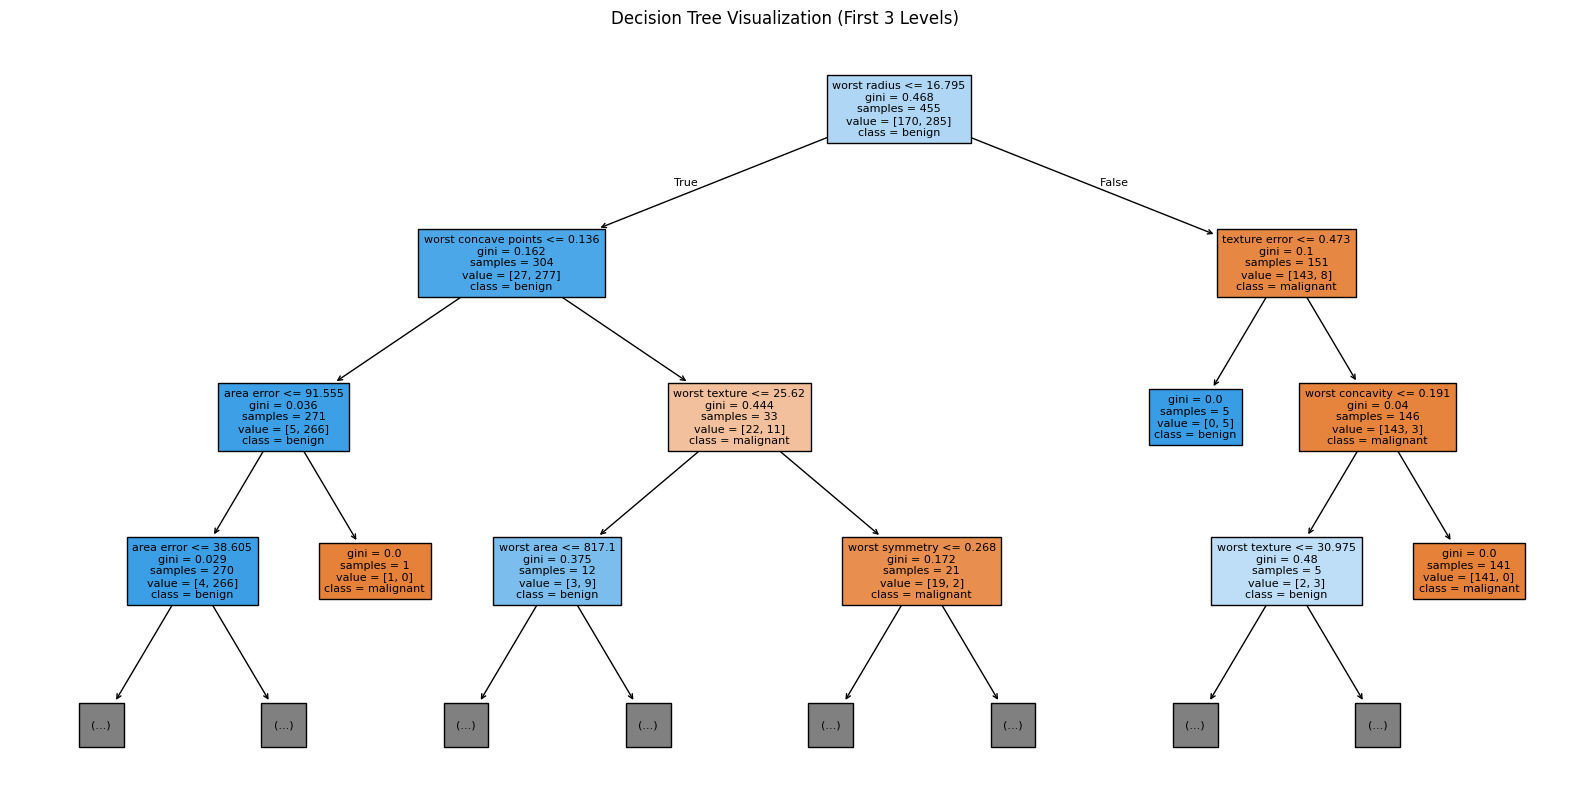

In [7]:
# Visualize the Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree Visualization (First 3 Levels)")
plt.show()

In [8]:
# Compare training and testing accuracy

train_accuracy = decision_tree.score(X_train, y_train)
test_accuracy = decision_tree.score(X_test, y_test)

print("Decision Tree Accuracy")
print("----------------------")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")


Decision Tree Accuracy
----------------------
Training Accuracy: 1.0000
Testing Accuracy : 0.9123


In [9]:
# Train a tuned Decision Tree with limited depth

tuned_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

tuned_tree.fit(X_train, y_train)

tuned_train_accuracy = tuned_tree.score(X_train, y_train)
tuned_test_accuracy = tuned_tree.score(X_test, y_test)

print("Tuned Decision Tree")
print("-------------------")
print(f"Training Accuracy: {tuned_train_accuracy:.4f}")
print(f"Testing Accuracy : {tuned_test_accuracy:.4f}")


Tuned Decision Tree
-------------------
Training Accuracy: 0.9868
Testing Accuracy : 0.9386


In [10]:
# Create and train a Random Forest classifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [11]:
# Evaluate Decision Tree and Random Forest

y_pred_tuned = tuned_tree.predict(X_test)
y_pred_forest = random_forest.predict(X_test)

results = pd.DataFrame({
    "Model": ["Tuned Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_forest)
    ]
})

print("Model Comparison")
print("----------------")
display(results.round(4))


Model Comparison
----------------


,Model,Accuracy
0,Tuned Decision Tree,0.9386
1,Random Forest,0.9561


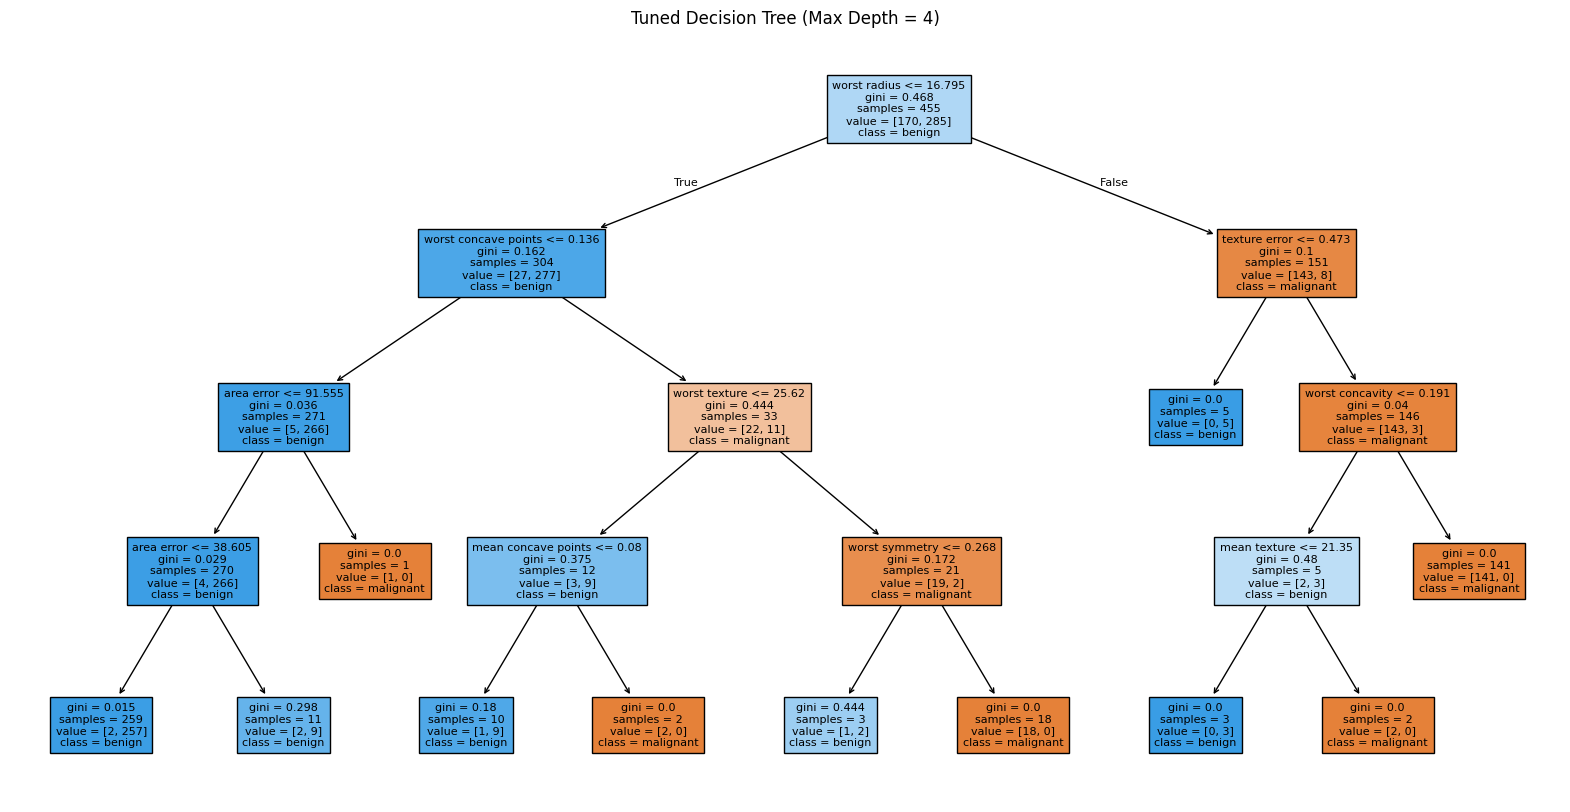

In [12]:
# Visualize the tuned Decision Tree

plt.figure(figsize=(20, 10))

plot_tree(
    tuned_tree,
    feature_names=X.columns,
    class_names=data.target_names,
    filled=True,
    max_depth=4,
    fontsize=8
)

plt.title("Tuned Decision Tree (Max Depth = 4)")
plt.show()

In [13]:
# Compare all three models using multiple evaluation metrics

models = {
    "Decision Tree": decision_tree,
    "Tuned Decision Tree": tuned_tree,
    "Random Forest": random_forest
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

print("Final Model Comparison")
print("----------------------")
display(results_df.round(4))

Final Model Comparison
----------------------


,Model,Accuracy
0,Decision Tree,0.9123
1,Tuned Decision Tree,0.9386
2,Random Forest,0.9561


In [14]:
# Simple tests for the trained models

assert len(y_pred_tuned) == len(y_test)
assert len(y_pred_forest) == len(y_test)

assert 0 <= accuracy_score(y_test, y_pred_tuned) <= 1
assert 0 <= accuracy_score(y_test, y_pred_forest) <= 1

print("All tests passed successfully!")

All tests passed successfully!


## W3D3 Summary

- Trained a Decision Tree classifier using Gini impurity.
- Evaluated the model using accuracy, classification report, and confusion matrix.
- Visualized the Decision Tree and checked for overfitting.
- Tuned the tree using `max_depth=4`.
- Trained a Random Forest classifier with 100 trees.
- Compared Decision Tree, Tuned Decision Tree, and Random Forest performance.
- Added automated tests to verify model predictions and accuracy values.

### Conclusion

The tuned Decision Tree reduces the complexity of the original tree and helps control overfitting. Random Forest combines multiple decision trees and can provide more robust classification performance.